In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
!pip install ipython-sql
!pip install imbalanced-learn

     -------------------------------------- 258.3/258.3 kB 8.0 MB/s eta 0:00:00
     ---------------------------------------- 309.1/309.1 kB ? eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0


In [7]:
df = pd.read_csv("PS_20174392719_1491204439457_log.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [8]:
df.shape

(6362620, 11)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [10]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [11]:
df["isFraud"].value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

In [12]:
import sqlite3

conn = sqlite3.connect("fraud.db")

df.to_sql("transactions", conn, if_exists="replace", index=False)

6362620

In [20]:
query = """
SELECT COUNT(*)
FROM transactions
WHERE isFraud = 1
"""

result = pd.read_sql(query, conn)

print(result)

   COUNT(*)
0      8213


In [21]:
pd.read_sql("""
SELECT COUNT(*)
FROM transactions
WHERE isFraud = 1
""", conn)

,COUNT(*)
0,8213


In [22]:
pd.read_sql("""
SELECT type, COUNT(*) AS fraud_count
FROM transactions
WHERE isFraud = 1
GROUP BY type
ORDER BY fraud_count DESC
""", conn)

,type,fraud_count
0,CASH_OUT,4116
1,TRANSFER,4097


In [23]:
pd.read_sql("""
SELECT AVG(amount)
FROM transactions
WHERE isFraud = 1
""", conn)

,AVG(amount)
0,1.467967e+06


# Exploratory Data Analysis

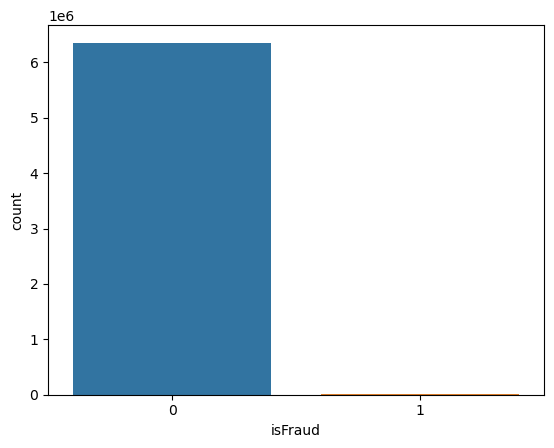

In [24]:
sns.countplot(x="isFraud", data=df)
plt.show()

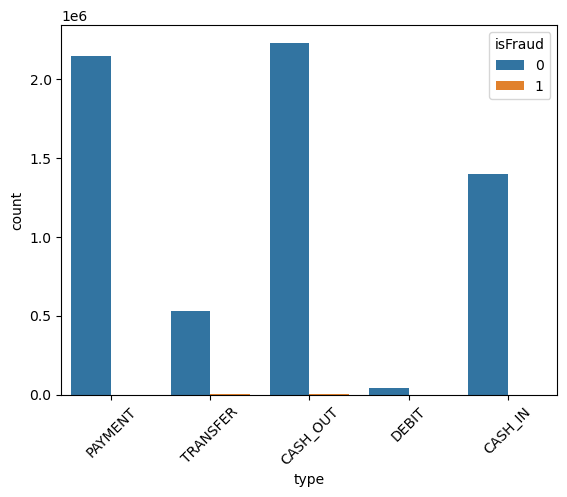

In [25]:
sns.countplot(x="type", hue="isFraud", data=df)
plt.xticks(rotation=45)
plt.show()

##### Transaction amount distribution.

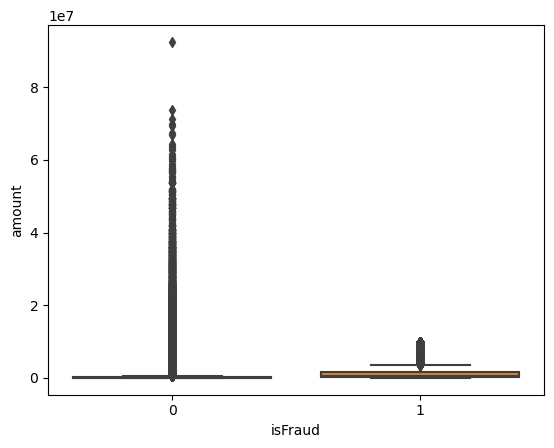

In [26]:
sns.boxplot(x="isFraud", y="amount", data=df)
plt.show()

# Feature Engineering

In [27]:
df["orig_balance_error"] = df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]

In [28]:
df["dest_balance_error"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

In [29]:
df["hour"] = df["step"] % 24

# Encode Transaction Type

In [30]:
le = LabelEncoder()

df["type"] = le.fit_transform(df["type"])

# Drop Unnecessary Columns

In [31]:
df = df.drop(["nameOrig", "nameDest"], axis=1)

# Split Data

In [32]:
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Handle Class Imbalance

In [35]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Train Model

In [36]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train_sm, y_train_sm)

RandomForestClassifier(random_state=42)

# Predictions

In [37]:
y_pred = model.predict(X_test)

# Evaluation

###### Confusion matrix.

In [38]:
confusion_matrix(y_test, y_pred)

array([[1270888,      16],
       [      4,    1616]], dtype=int64)

###### Classification report

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.99      1.00      0.99      1620

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



###### ROC score.

In [40]:
roc_auc_score(y_test, y_pred)

0.9987591373668266

# Feature Importance

In [41]:
importance = model.feature_importances_

features = X.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(imp_df)

               Feature  Importance
8   orig_balance_error    0.380174
4       newbalanceOrig    0.182522
3        oldbalanceOrg    0.154145
2               amount    0.107355
1                 type    0.068805
9   dest_balance_error    0.038025
0                 step    0.020724
6       newbalanceDest    0.019355
10                hour    0.018135
5       oldbalanceDest    0.010108
7       isFlaggedFraud    0.000652


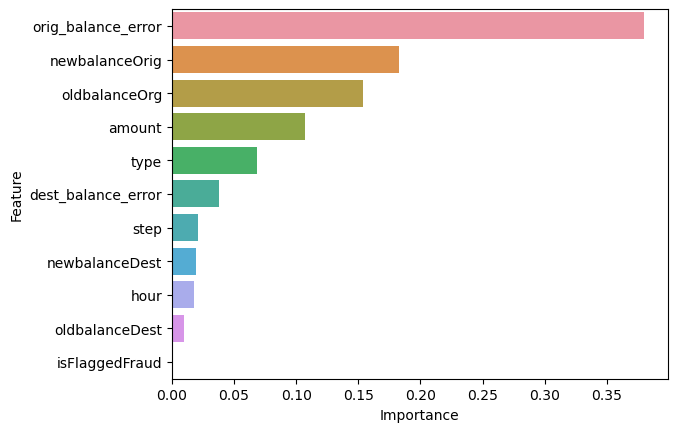

In [42]:
sns.barplot(x="Importance", y="Feature", data=imp_df)
plt.show()